# Creating Synthetic Valid Credal Sets

In [45]:
import sys
import os
import pickle
root_path = os.path.abspath('..')
sys.path.append(root_path)

import numpy as np
from src.helper import is_in_convex_hull_lp_batch_robust
from src.BPS import solve_b_in_batches, cond_cvg
from src.paper_plots import colorblind_codes, figsizes, sns_contexts, make_full_page_figure
import matplotlib.pyplot as plt

In [2]:

def generate_controlled_credal_sets(n, m, k):
    all_vertices = np.zeros((n, m, k))
    true_probs = np.zeros((n, k))
    
    
    for i in range(n):
        # 1. Pick a 'base' behavior for this instance
        base_dist = np.random.dirichlet([1.0] * k)
        
        # 2. Control size: eta determines how tight vertices are to base_dist
        # Small eta = Large Hull; Large eta = Tiny Hull
        eta = np.exp(np.random.uniform(2, 5)) 
        
        # 3. Sample vertices from a Dirichlet centered at base_dist
        vertices = np.random.dirichlet(eta * base_dist, size=m)
        all_vertices[i] = vertices
        
        # 4. True probability is a random point inside this hull
        weights = np.random.dirichlet([1.0] * m)
        true_probs[i] = weights @ vertices
            
    return all_vertices, true_probs

In [3]:
import random 
seed=2026
random.seed(seed)
np.random.seed(seed)
K = 5 
credal_sets, true_probs = generate_controlled_credal_sets(1000, 10, K)

In [4]:
nominal_coverage =0.9

credal_cvg = is_in_convex_hull_lp_batch_robust(true_probs, credal_sets, tol=1e-6)
sets = solve_b_in_batches(credal_sets, nominal_coverage, batch_size=100)
sets_APS = solve_b_in_batches(credal_sets.mean(axis=1, keepdims=True), nominal_coverage, batch_size=100)
set_sizes = np.sum(sets, axis=1)
cond_coverage = cond_cvg(sets, true_probs)
cond_sat = cond_coverage >= nominal_coverage - 1e-6
set_sizes_APS = np.sum(sets_APS, axis=1)
cond_coverage_APS = cond_cvg(sets_APS, true_probs)
cond_sat = cond_coverage_APS >= nominal_coverage - 1e-6

100%|██████████| 1000/1000 [00:01<00:00, 980.00it/s]


In [5]:
np.mean(set_sizes)

np.float64(3.69465811284952)

In [6]:
np.mean(cond_coverage)

np.float64(0.9323107012957239)

In [7]:
print(credal_cvg.mean())

1.0


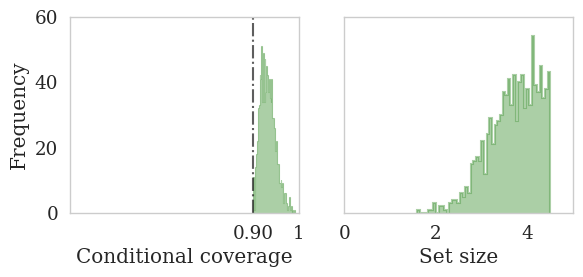

In [9]:
from sklearn.model_selection import train_test_split
from src.BPS import *
f, axs= make_full_page_figure(style="ICML", n_cols=2, relative_figsize=(1, 1.5), sharey=True)
bins = 50

axs[0].hist(cond_coverage, bins=bins, alpha=0.5,  histtype='step', fill=True, color=colorblind_codes["green"])
axs[1].hist(set_sizes, bins=bins, linewidth=1.5, histtype='step', alpha=0.5, fill=True, color=colorblind_codes["green"])
axs[0].axvline(nominal_coverage, c="k", linewidth=1.5, alpha=0.7, linestyle="-.")
axs[0].set_xticks([0, nominal_coverage, 1])
axs[0].set_xticklabels(["0", f"{nominal_coverage:.2f}", "1"])
axs[0].set_yticks([0, 20, 40, 60])
axs[0].set_xlim([0.5,1])
axs[1].set_xlim([0,K])
axs[0].set_xlabel("Conditional coverage")
axs[1].set_xlabel("Set size")
axs[0].set_ylabel("Frequency")
axs[0].grid(False)
axs[1].grid(False)
# axs[d].set_title(["CIFAR-10", "ChaosNLI", "QualityMRI"][d], fontweight="bold")
# axs[d].tick_params(axis='x', labelsize=8)
# # plt.rcParams["font.family"] = "Times New Roman"
# # 
# axs[0].legend(["BPS"+r"$(1-\alpha)$", "Calibrated BPS with first-order data", "Calibrated BPS with zero-order data", r"Desired Coverage $(1-\alpha)$"])
os.makedirs(os.path.join(root_path, "all_figures", "valid"), exist_ok=True)
# plt.savefig(os.path.join(root_path, "all_figures", "valid", "BPS.pdf"), format="pdf", bbox_inches='tight', pad_inches=0)

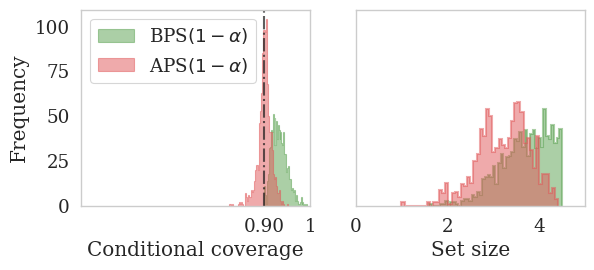

In [10]:
f, axs= make_full_page_figure(style="ICML", n_cols=2, relative_figsize=(1, 1.5), sharey=True)
bins = 50

axs[0].hist(cond_coverage, bins=bins, alpha=0.5,  histtype='step', fill=True, color=colorblind_codes["green"], label=r"BPS$(1-\alpha)$")
axs[0].hist(cond_coverage_APS, bins=bins, alpha=0.5,  histtype='step', fill=True, color=colorblind_codes["red"], label=r"APS$(1-\alpha)$")
axs[1].hist(set_sizes, bins=bins, linewidth=1.5, histtype='step', alpha=0.5, fill=True, color=colorblind_codes["green"])
axs[1].hist(set_sizes_APS, bins=bins, linewidth=1.5, histtype='step', alpha=0.5, fill=True, color=colorblind_codes["red"])
axs[0].axvline(nominal_coverage, c="k", linewidth=1.5, alpha=0.7, linestyle="-.")
axs[0].set_xticks([0, nominal_coverage, 1])
axs[0].set_xticklabels(["0", f"{nominal_coverage:.2f}", "1"])
# axs[0].set_yticks([0, 20, 40, 60])
axs[0].set_xlim([0.5,1])
axs[1].set_xlim([0,K])
axs[0].set_xlabel("Conditional coverage")
axs[1].set_xlabel("Set size")
axs[0].set_ylabel("Frequency")
axs[0].grid(False)
axs[1].grid(False)
axs[0].legend()
# axs[d].set_title(["CIFAR-10", "ChaosNLI", "QualityMRI"][d], fontweight="bold")
# axs[d].tick_params(axis='x', labelsize=8)
# # plt.rcParams["font.family"] = "Times New Roman"
# # 
# axs[0].legend(["BPS"+r"$(1-\alpha)$", "Calibrated BPS with first-order data", "Calibrated BPS with zero-order data", r"Desired Coverage $(1-\alpha)$"])
os.makedirs(os.path.join(root_path, "all_figures", "valid"), exist_ok=True)
# plt.savefig(os.path.join(root_path, "all_figures", "valid", "BPSvsAPS.pdf"), format="pdf", bbox_inches='tight', pad_inches=0)

In [63]:
import random
K = 3
nominal_coverage = 0.9
# s = np.random.randint(0,1000)
# print(s)
while True:
    # random.seed(s)
    # np.random.seed(s)
    credal_sets, true_probs = generate_controlled_credal_sets(1, 6, K)
    y = np.random.choice([0,1,2], p=true_probs.flatten())
    sets_BPS = solve_b_in_batches(credal_sets, nominal_coverage, batch_size=100)
    C_BPS = np.random.binomial(1, p=np.clip(sets_BPS.flatten(), 0, 1))
    sets_APS = solve_b_in_batches(credal_sets.mean(axis=1, keepdims=True), nominal_coverage, batch_size=100)
    C_APS = np.random.binomial(1, p=np.clip(sets_APS.flatten(), 0, 1))
    # if C_BPS[y] == True and C_APS[y] == False and np.abs(credal_sets.mean(axis=1).flatten() - true_probs.flatten()).sum() > 0.2 and credal_sets.mean(axis=1).flatten()[y]<1-nominal_coverage:
    # if C_BPS[y] == True and C_APS[y] == False and credal_sets.mean(axis=1).flatten()[y]<1-nominal_coverage:
    # if C_BPS[y] == True and C_APS[y] == False and C_BPS.sum()==2 and C_APS.sum()==1:
    if (sets_BPS@true_probs.flatten() >=  nominal_coverage) and (sets_APS@true_probs.flatten() <=  nominal_coverage - 0.1):
        print("label:", y+1)
        print("true p:", true_probs.flatten())
        print("credal set mean:", credal_sets.mean(axis=1).flatten())
        print("APS set:", C_APS)
        print("BPS set:", C_BPS)
        print("APS conditional coverage", sets_APS@true_probs.flatten() )
        print("BPS conditional coverage:", sets_BPS@true_probs.flatten() )
        break
        
    # else:
    #     s = s+1



label: 1
true p: [0.14978774 0.53516644 0.31504582]
credal set mean: [0.05726072 0.70293045 0.23980884]
APS set: [0 1 1]
BPS set: [1 1 1]
APS conditional coverage [0.79406407]
BPS conditional coverage: [0.9297603]


array([0.93557346])

In [62]:
sets_APS@true_probs.flatten()

array([0.79598526])

In [54]:
sets_BPS@true_probs.flatten()

array([0.88329135])

In [34]:
credal_sets.mean(axis=1).flatten()[y]

np.float64(0.3092585884527154)

np.float64(0.05621632142964201)

In [11]:
sets_APS

array([[-5.78618995e-11,  9.66048000e-01, -4.96774477e-11]])

In [4]:
C_APS

array([0, 1, 1])

In [5]:
C_BPS

array([1, 1, 1])

In [6]:
y

np.int64(0)

In [46]:
import mpltern
import matplotlib.pyplot as plt
from scipy.stats import entropy 
from mpltern.datasets import get_dirichlet_pdfs
from matplotlib.colors import TwoSlopeNorm

In [47]:
import seaborn as sns
from epiuc.utils.paper_plots import figsizes, sns_contexts

def make_full_page_figure(style, n_rows=1, n_cols=1, relative_figsize=(1, 1), **kwargs):
    sns.set_theme(**sns_contexts[style])
    figsize = figsizes[style]["full"]
    figsize = (figsize[0] * relative_figsize[0], figsize[1] * relative_figsize[1])
    f, axs = plt.subplots(n_rows, n_cols, figsize=figsize, **kwargs)
    axs_iter = np.atleast_1d(axs).flat
    for ax in axs_iter:
        for spine in ax.spines.values():
            spine.set_visible(False)
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        ax.grid(False)
    return f, axs

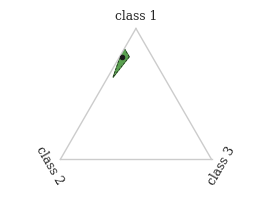

In [52]:
from scipy.spatial import ConvexHull

credal_means = credal_sets.mean(axis=1).flatten()

hull_credal_sets = ConvexHull(credal_sets.squeeze()[:, :2])
a_credal_sets, b_credal_sets, c_credal_sets = credal_sets.squeeze()[:, 0], credal_sets.squeeze()[:, 1], credal_sets.squeeze()[:, 2]

f, axs= make_full_page_figure(style="ICML", n_cols=1, relative_figsize=(0.5, 1))
ax = f.add_subplot(projection="ternary")

ax.set_tlabel("class 1")
ax.set_llabel("class 2")
ax.set_rlabel("class 3")
ax.tick_params(tick1On=False, tick2On=False, label1On=False, label2On=False)
ax.grid(False)

# color= "#2a9d8f" if coverage_convex_hull(credal_sets, credal_means.unsqueeze(0)) else "#e76f51"
# ax.scatter(p[0], p[1], p[2], s=10, color=colorblind_codes["blue"], marker="s", zorder=3)
# for i in range(credal_sets.shape[1]):
#     ax.scatter(credal_sets[0,i,0], credal_sets[0,i,1], credal_sets[0,i,2], s=10, color="green", edgecolors="k", zorder=3)
ax.scatter(credal_means[0], credal_means[1], credal_means[2], s=10, color='k', zorder=3)
# ax.scatter(true_probs.flatten()[0], true_probs.flatten()[1], true_probs.flatten()[2], s=10, color='r', zorder=3)
# Extract and plot hull edges
for s in hull_credal_sets.simplices:
    i, j = s
    ax.plot(
        [a_credal_sets[i], a_credal_sets[j]],
        [b_credal_sets[i], b_credal_sets[j]],
        [c_credal_sets[i], c_credal_sets[j]],
        color='k',
        linestyle='--',
        linewidth=0.5
    )
# Get the convex hull vertices in order
hull_indices = hull_credal_sets.vertices
a_hull = a_credal_sets[hull_indices]
b_hull = b_credal_sets[hull_indices]
c_hull = c_credal_sets[hull_indices]


# Fill the convex hull area
ax.fill(a_hull, b_hull, c_hull, color=colorblind_codes["green"], alpha=1, label="credal_sets")
os.makedirs(os.path.join(root_path, "all_figures", "valid_invalid_credals_6"), exist_ok=True)
# plt.savefig(os.path.join(root_path, "all_figures", "valid_invalid_credals_6", str(int(100*d))+".pdf"), format="pdf", bbox_inches='tight', pad_inches=0)
# plt.legend(loc="upper left")

In [49]:
credal_means.shape

(3,)